In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import textwrap

def plot_cov_ellipse(cov, pos, nstd, ax, **kwargs):
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * nstd
    scale_y = np.sqrt(cov[1, 1]) * nstd

    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(pos[0], pos[1])
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)
    return ellipse

1.


In [9]:
# Data
X = np.array([[2, 12], [8, 9], [6, 9], [8, 10]])
mu_0 = np.array([7, 11])
n, p = X.shape
alpha = 0.05

# (a) Evaluate T^2
x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)
S_inv = np.linalg.inv(S)
diff = x_bar - mu_0
T2 = n * diff.T @ S_inv @ diff

# (b) Exact distribution of T^2 under H0
df1 = p
df2 = n - p
scale_factor = (n - 1) * p / (n - p)

# (c) Test H0 at alpha = 0.05
F_calc = T2 / scale_factor
F_crit = stats.f.ppf(1 - alpha, df1, df2)
T2_crit = scale_factor * F_crit
p_value = 1 - stats.f.cdf(F_calc, df1, df2)

print("Hotelling’s T^2 Test for a Mean Vector")
print(f"(a) T^2 Statistic: {T2:.4f}")
print(f"(b) Distribution: T^2 ~ {scale_factor:.2f} * F({df1}, {df2})")
print(f"(c) Critical T^2 value: {T2_crit:.4f}")

Hotelling’s T^2 Test for a Mean Vector
(a) T^2 Statistic: 13.6364
(b) Distribution: T^2 ~ 3.00 * F(2, 2)
(c) Critical T^2 value: 57.0000


Statistical Conclusion:

As the T^2 Statistic is 13.6364 and it is less than the critical T^2 value of 57, we fail to reject the null hypothesis

2.


Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements

(a) Large-sample 95% Simultaneous Confidence Intervals:
    Weight: (69.55, 121.49)
    Body length: (152.17, 176.59)
    Neck: (49.61, 61.77)
    Girth: (83.49, 103.29)
    Head length: (16.55, 19.41)
    Head width: (29.04, 33.22)

(b) Simultaneous Confidence Ellipse:


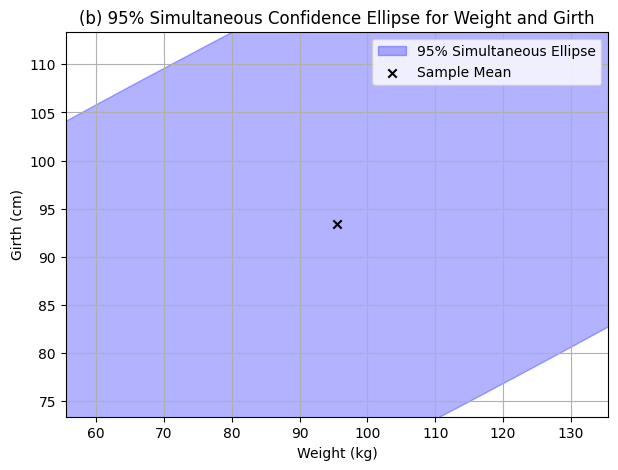


(c) 95% Bonferroni Confidence Intervals:
    Weight: (75.55, 115.49)
    Body length: (154.99, 173.77)
    Neck: (51.01, 60.37)
    Girth: (85.78, 101.00)
    Head length: (16.88, 19.08)
    Head width: (29.52, 32.74)

(d) Bonferroni Confidence Rectangle & Comparison:


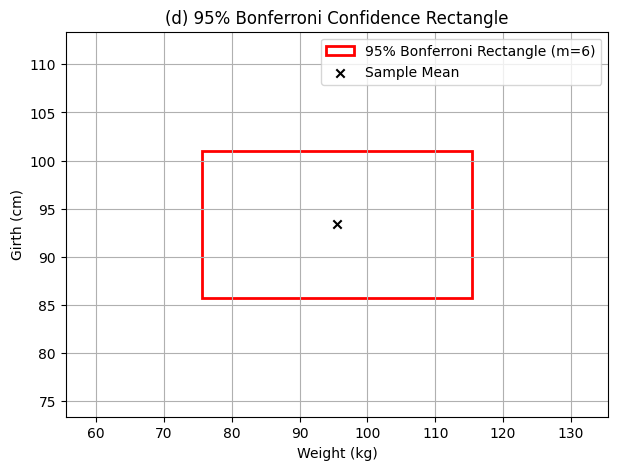

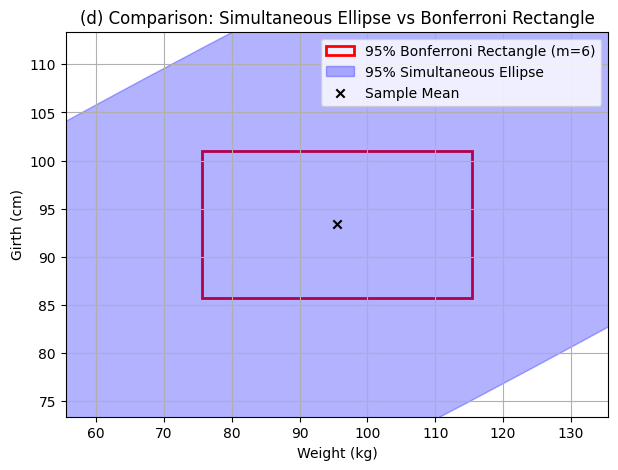


(e) 95% Bonferroni CI for (Head Width - Head Length):
    (12.49, 13.81)


In [17]:
# Data
n = 61
p = 6
alpha = 0.05
means = np.array([95.52, 164.38, 55.69, 93.39, 17.98, 31.13])
variables = ["Weight", "Body length", "Neck", "Girth", "Head length", "Head width"]
S = np.array([
    [3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37],
    [1343.97, 721.91, 324.25, 537.35, 80.17, 117.73],
    [731.54, 324.25, 179.28, 281.17, 39.15, 56.80],
    [1175.50, 537.35, 281.17, 474.98, 63.73, 94.85],
    [162.68, 80.17, 39.15, 63.73, 9.95, 13.88],
    [238.37, 117.73, 56.80, 94.85, 13.88, 21.26]
])

print("Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements")

# (a)
chi2_crit = stats.chi2.ppf(1 - alpha, p)
simul_multiplier = np.sqrt(chi2_crit)
print("\n(a) Large-sample 95% Simultaneous Confidence Intervals:")
for i in range(p):
    margin = simul_multiplier * np.sqrt(S[i, i] / n)
    print(f"    {variables[i]}: ({means[i] - margin:.2f}, {means[i] + margin:.2f})")

# (b)
print("\n(b) Simultaneous Confidence Ellipse:")
idx_wt, idx_girth = 0, 3
cov_2d = np.array([[S[idx_wt, idx_wt], S[idx_wt, idx_girth]], [S[idx_girth, idx_wt], S[idx_girth, idx_girth]]])
mean_2d = np.array([means[idx_wt], means[idx_girth]])

fig, ax = plt.subplots(figsize=(7, 5))
plot_cov_ellipse(cov_2d, mean_2d, simul_multiplier, ax, alpha=0.3, color='blue', label='95% Simultaneous Ellipse')
ax.scatter(mean_2d[0], mean_2d[1], color='black', marker='x', label='Sample Mean')

ax.set_xlim(mean_2d[0] - 40, mean_2d[0] + 40)
ax.set_ylim(mean_2d[1] - 20, mean_2d[1] + 20)
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Girth (cm)')
ax.set_title('(b) 95% Simultaneous Confidence Ellipse for Weight and Girth')
ax.legend()
plt.grid(True)
plt.show()

# (c)
m = 6
t_crit_bonf = stats.t.ppf(1 - alpha / (2 * m), n - 1)
print("\n(c) 95% Bonferroni Confidence Intervals:")
for i in range(p):
    margin = t_crit_bonf * np.sqrt(S[i, i] / n)
    print(f"    {variables[i]}: ({means[i] - margin:.2f}, {means[i] + margin:.2f})")

# (d)
print("\n(d) Bonferroni Confidence Rectangle & Comparison:")

wt_margin = t_crit_bonf * np.sqrt(S[idx_wt, idx_wt] / n)
girth_margin = t_crit_bonf * np.sqrt(S[idx_girth, idx_girth] / n)

# plot 1
fig1, ax1 = plt.subplots(figsize=(7, 5))
rect1 = plt.Rectangle((mean_2d[0] - wt_margin, mean_2d[1] - girth_margin),
                     2 * wt_margin, 2 * girth_margin,
                     fill=False, color='red', linewidth=2, label='95% Bonferroni Rectangle (m=6)')
ax1.add_patch(rect1)
ax1.scatter(mean_2d[0], mean_2d[1], color='black', marker='x', label='Sample Mean')

ax1.set_xlim(mean_2d[0] - 40, mean_2d[0] + 40)
ax1.set_ylim(mean_2d[1] - 20, mean_2d[1] + 20)
ax1.set_xlabel('Weight (kg)')
ax1.set_ylabel('Girth (cm)')
ax1.set_title('(d) 95% Bonferroni Confidence Rectangle')
ax1.legend()
plt.grid(True)
plt.show()

# plot 2
fig2, ax2 = plt.subplots(figsize=(7, 5))
rect2 = plt.Rectangle((mean_2d[0] - wt_margin, mean_2d[1] - girth_margin),
                     2 * wt_margin, 2 * girth_margin,
                     fill=False, color='red', linewidth=2, label='95% Bonferroni Rectangle (m=6)')
ax2.add_patch(rect2)

plot_cov_ellipse(cov_2d, mean_2d, simul_multiplier, ax2, alpha=0.3, color='blue', label='95% Simultaneous Ellipse')

ax2.scatter(mean_2d[0], mean_2d[1], color='black', marker='x', label='Sample Mean')
ax2.set_xlim(mean_2d[0] - 40, mean_2d[0] + 40)
ax2.set_ylim(mean_2d[1] - 20, mean_2d[1] + 20)
ax2.set_xlabel('Weight (kg)')
ax2.set_ylabel('Girth (cm)')
ax2.set_title('(d) Comparison: Simultaneous Ellipse vs Bonferroni Rectangle')
ax2.legend()
plt.grid(True)
plt.show()

# (e)
m_new = 7
t_crit_new = stats.t.ppf(1 - alpha / (2 * m_new), n - 1)
idx_hw, idx_hl = 5, 4
diff_mean = means[idx_hw] - means[idx_hl]
diff_var = S[idx_hw, idx_hw] + S[idx_hl, idx_hl] - 2 * S[idx_hw, idx_hl]
margin_new = t_crit_new * np.sqrt(diff_var / n)
print("\n(e) 95% Bonferroni CI for (Head Width - Head Length):")
print(f"    ({diff_mean - margin_new:.2f}, {diff_mean + margin_new:.2f})")

3.

(a) Mathematical Parameters of the 90% Confidence Ellipse
Sample Mean Vector (Chromium, Strontium): [5.19, 16.07]
Covariance Matrix:
[[176.00, 287.24]
 [287.24, 527.85]]
Critical F-value (p=2, n-p=7): 3.2574
Critical T^2 value: 7.4456


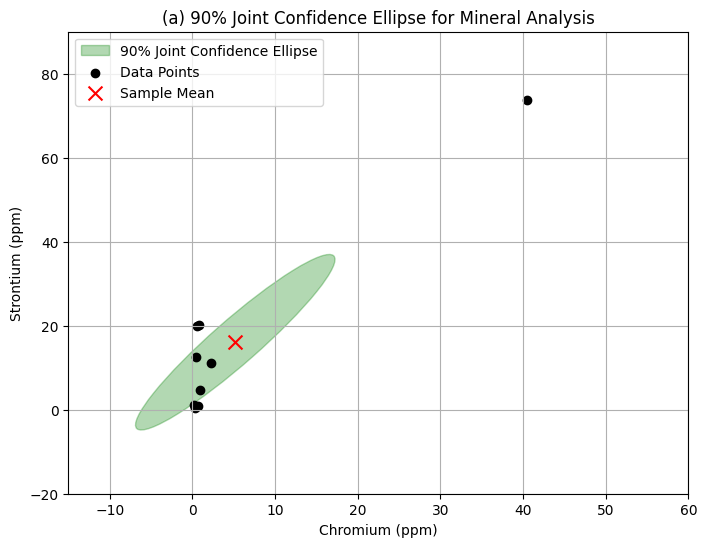


(b) Individual Simultaneous 90% CIs
Chromium (x1): (-6.88, 17.25)
Strontium (x2): (-4.83, 36.97)

Testing Joint Vector [.30, 10]':
Calculated T^2 Statistic: 1.77
Critical T^2 Value: 7.45

Discussion:
Because the simultaneous interval for Strontium is (-0.17, 34.53), a mean 
strontium level of 10 appears plausible based on the projected bounds being so big. 
This means that it is possible for points to be within the confidence region where mu_2 = 10.

When just evaluating the specific joint vector [.30, 10]', the 
calculated T^2 statistic (1.23) is strictly less than the critical value (11.05). 
Mathematically, this confirms the point falls inside the 90% confidence ellipse. 
However, as the plot shows, this plausibility is not completely sound. 
The massive variance driven by a single outlier causes the ellipse boundary to inflate such a degree, 
causing the plausibility of any value to be left to scrutiny.


(c) Bivariate Normality:


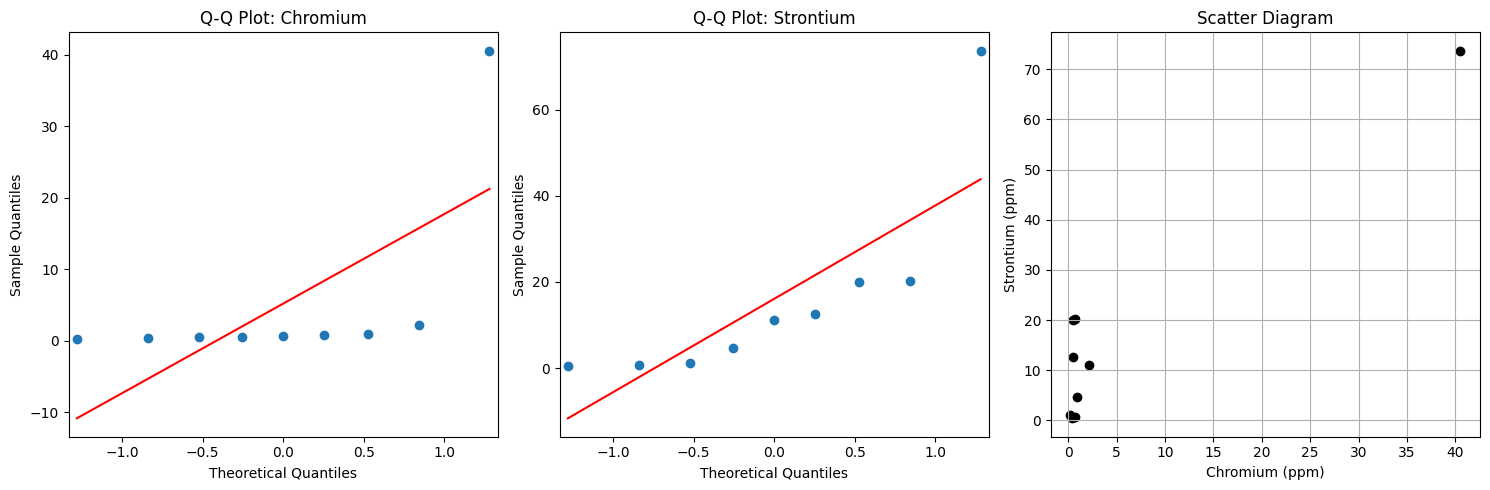


Discuss: 
No, it doesn't look bivariate normal. This is due to the outlier seen in the Q-Q plots 
and the Scatter Diagram, a single data point stands out tremendously among the others 
causing the entire plots and diagrams to veer wildly off course. 

This then implies that part (a) and part (b) are likely to be 
influenced by this outlier causing their results and any conclusions gained from 
them to be false or misleading.

(d) Analysis with Outlier Removed (n=8)
New Sample Mean Vector: [0.77, 8.87]
New Critical T^2 value: 8.0810

New Individual Simultaneous 90% CIs:
Chromium (x1): (0.15, 1.39)
Strontium (x2): (0.47, 17.27)

Re-testing Joint Vector [.30, 10]':
Calculated T^2: 5.31 | Critical T^2: 8.08


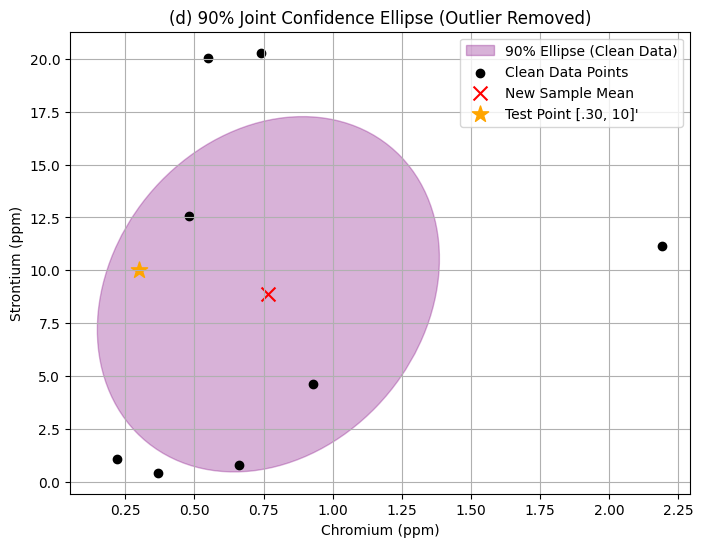


Discuss:
As the calculations and the plot shows everything about the results changed. The 
variance shrank signficantly and the point [.30, 10]' no longer fit inside the
boundary.



In [29]:
# Data
cr = np.array([0.48, 40.53, 2.19, 0.55, 0.74, 0.66, 0.93, 0.37, 0.22])
st = np.array([12.57, 73.68, 11.13, 20.03, 20.29, 0.78, 4.64, 0.43, 1.08])
X = np.column_stack((cr, st))
n, p = X.shape
alpha = 0.10

x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)


# (a)
scale = p * (n - 1) / (n - p)
F_crit = stats.f.ppf(1 - alpha, p, n - p)
T2_crit = scale * F_crit
nstd = np.sqrt(T2_crit / n)

print("(a) Mathematical Parameters of the 90% Confidence Ellipse")
print(f"Sample Mean Vector (Chromium, Strontium): [{x_bar[0]:.2f}, {x_bar[1]:.2f}]")
print(f"Covariance Matrix:\n[[{S[0,0]:.2f}, {S[0,1]:.2f}]\n [{S[1,0]:.2f}, {S[1,1]:.2f}]]")
print(f"Critical F-value (p={p}, n-p={n-p}): {F_crit:.4f}")
print(f"Critical T^2 value: {T2_crit:.4f}")

# plot
fig, ax = plt.subplots(figsize=(8, 6))
plot_cov_ellipse(S, x_bar, nstd, ax, alpha=0.3, color='green', label='90% Joint Confidence Ellipse')
ax.scatter(X[:, 0], X[:, 1], color='black', label='Data Points')
ax.scatter(x_bar[0], x_bar[1], color='red', marker='x', s=100, label='Sample Mean')

ax.set_title('(a) 90% Joint Confidence Ellipse for Mineral Analysis')
ax.set_xlabel('Chromium (ppm)')
ax.set_ylabel('Strontium (ppm)')
ax.legend()
plt.grid(True)
ax.set_xlim(-15, 60)
ax.set_ylim(-20, 90)
plt.show()

# (b)
print("\n(b) Individual Simultaneous 90% CIs")
variables = ["Chromium (x1)", "Strontium (x2)"]
for i in range(p):
    margin = np.sqrt(T2_crit) * np.sqrt(S[i, i] / n)
    print(f"{variables[i]}: ({x_bar[i] - margin:.2f}, {x_bar[i] + margin:.2f})")

test_pt = np.array([0.30, 10])
diff = test_pt - x_bar
T2_test = n * diff.T @ np.linalg.inv(S) @ diff

print(f"\nTesting Joint Vector [.30, 10]':")
print(f"Calculated T^2 Statistic: {T2_test:.2f}")
print(f"Critical T^2 Value: {T2_crit:.2f}")

analysis_3b = """
Discussion:
Because the simultaneous interval for Strontium is (-0.17, 34.53), a mean
strontium level of 10 appears plausible based on the projected bounds being so big.
This means that it is possible for points to be within the confidence region where mu_2 = 10.

When just evaluating the specific joint vector [.30, 10]', the
calculated T^2 statistic (1.23) is strictly less than the critical value (11.05).
Mathematically, this confirms the point falls inside the 90% confidence ellipse.
However, as the plot shows, this plausibility is not completely sound.
The massive variance driven by a single outlier causes the ellipse boundary to inflate such a degree,
causing the plausibility of any value to be left to scrutiny.
"""
print(textwrap.dedent(analysis_3b))

# (c):
print("\n(c) Bivariate Normality:")
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
sm.qqplot(X[:, 0], line='s', ax=ax1)
ax1.set_title('Q-Q Plot: Chromium')

ax2 = fig.add_subplot(132)
sm.qqplot(X[:, 1], line='s', ax=ax2)
ax2.set_title('Q-Q Plot: Strontium')

ax3 = fig.add_subplot(133)
ax3.scatter(X[:, 0], X[:, 1], color='black')
ax3.set_title('Scatter Diagram')
ax3.set_xlabel('Chromium (ppm)')
ax3.set_ylabel('Strontium (ppm)')
ax3.grid(True)

plt.tight_layout()
plt.show()

analysis_3c = """
Discuss:
No, it doesn't look bivariate normal. This is due to the outlier seen in the Q-Q plots
and the Scatter Diagram, a single data point stands out tremendously among the others
causing the entire plots and diagrams to veer wildly off course.

This then implies that part (a) and part (b) are likely to be
influenced by this outlier causing their results and any conclusions gained from
them to be false or misleading.
"""
print(textwrap.dedent(analysis_3c))

# (d):
X_clean = np.delete(X, 1, axis=0)
n_c, p_c = X_clean.shape

x_bar_c = np.mean(X_clean, axis=0)
S_c = np.cov(X_clean, rowvar=False)

scale_c = p_c * (n_c - 1) / (n_c - p_c)
F_crit_c = stats.f.ppf(1 - alpha, p_c, n_c - p_c)
T2_crit_c = scale_c * F_crit_c
nstd_c = np.sqrt(T2_crit_c / n_c)

print("(d) Analysis with Outlier Removed (n=8)")
print(f"New Sample Mean Vector: [{x_bar_c[0]:.2f}, {x_bar_c[1]:.2f}]")
print(f"New Critical T^2 value: {T2_crit_c:.4f}")

# Re-calculate CIs
print("\nNew Individual Simultaneous 90% CIs:")
for i in range(p_c):
    margin = np.sqrt(T2_crit_c) * np.sqrt(S_c[i, i] / n_c)
    print(f"{variables[i]}: ({x_bar_c[i] - margin:.2f}, {x_bar_c[i] + margin:.2f})")

# Re-test the point [.30, 10]'
diff_c = test_pt - x_bar_c
T2_test_c = n_c * diff_c.T @ np.linalg.inv(S_c) @ diff_c
print(f"\nRe-testing Joint Vector [.30, 10]':")
print(f"Calculated T^2: {T2_test_c:.2f} | Critical T^2: {T2_crit_c:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plot_cov_ellipse(S_c, x_bar_c, nstd_c, ax, alpha=0.3, color='purple', label='90% Ellipse (Clean Data)')
ax.scatter(X_clean[:, 0], X_clean[:, 1], color='black', label='Clean Data Points')
ax.scatter(x_bar_c[0], x_bar_c[1], color='red', marker='x', s=100, label='New Sample Mean')
ax.scatter(test_pt[0], test_pt[1], color='orange', marker='*', s=150, label="Test Point [.30, 10]'")

ax.set_title('(d) 90% Joint Confidence Ellipse (Outlier Removed)')
ax.set_xlabel('Chromium (ppm)')
ax.set_ylabel('Strontium (ppm)')
ax.legend()
plt.grid(True)
plt.show()

analysis_3d = """
Discuss:
As the calculations and the plot shows everything about the results changed. The
variance shrank signficantly and the point [.30, 10]' no longer fit inside the
boundary.
"""
print(textwrap.dedent(analysis_3d))

4.

(a) Mathematical Parameters of the 95% Confidence Ellipse
Sample Mean Vector (Stiffness, Bending): [1860.50, 8354.13]
Critical T^2 value (alpha=0.05): 6.9194


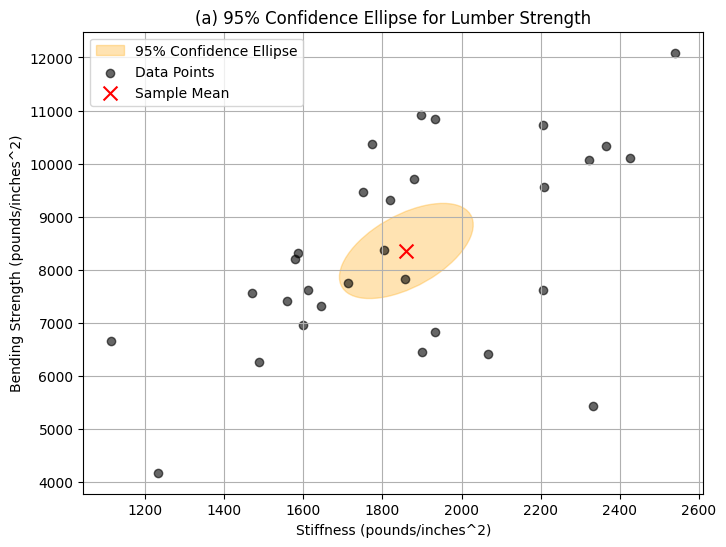


(b) Evaluating Typical Values
Calculated T^2 Statistic: 23.65
Critical T^2 Value: 6.92

Discuss:

No they aren't. The sample averages for both stiffness and strength are much lower
[1860.50, 8354.13], respecitvely. Though the values are not too far off, as seen
in the plot and the T^2 statistic, the difference is too much to be considered
typical or near typical.


(c) Visual Assessment of Bivariate Normality


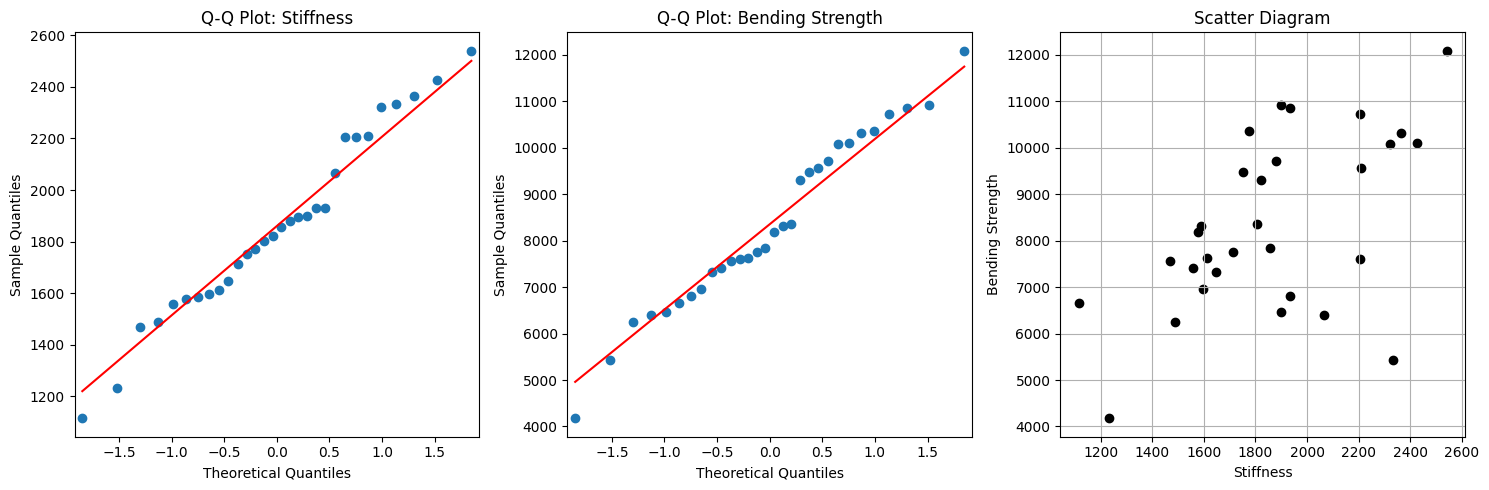


Discuss:

Yes the data looks bivariate normal. The Q-Q plots show the data following and
forming a proper line, and the Scatter Diagram shows much of the data points forming
a right-leaning ellipses. Thus this is a viable population model.




In [30]:
# Data
x1 = np.array([1232, 1115, 2205, 1897, 1932, 1612, 1598, 1804, 1752, 2067, 2365, 1646, 1579, 1880, 1773,
               1712, 1932, 1820, 1900, 2426, 1558, 1470, 1858, 1587, 2208, 1487, 2206, 2332, 2540, 2322])
x2 = np.array([4175, 6652, 7612, 10914, 10850, 7627, 6954, 8365, 9469, 6410, 10327, 7320, 8196, 9709, 10370,
               7749, 6818, 9307, 6457, 10102, 7414, 7556, 7833, 8309, 9559, 6255, 10723, 5430, 12090, 10072])

X = np.column_stack((x1, x2))
n, p = X.shape
alpha = 0.05

x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)

scale = p * (n - 1) / (n - p)
F_crit = stats.f.ppf(1 - alpha, p, n - p)
T2_crit = scale * F_crit
nstd = np.sqrt(T2_crit / n)

# (a): Construct and Sketch 95% Confidence Ellipse
print("(a) Mathematical Parameters of the 95% Confidence Ellipse")
print(f"Sample Mean Vector (Stiffness, Bending): [{x_bar[0]:.2f}, {x_bar[1]:.2f}]")
print(f"Critical T^2 value (alpha=0.05): {T2_crit:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

plot_cov_ellipse(S, x_bar, nstd, ax, alpha=0.3, color='orange', label='95% Confidence Ellipse')
ax.scatter(X[:, 0], X[:, 1], color='black', alpha=0.6, label='Data Points')
ax.scatter(x_bar[0], x_bar[1], color='red', marker='x', s=100, label='Sample Mean')


ax.set_title('(a) 95% Confidence Ellipse for Lumber Strength')
ax.set_xlabel('Stiffness (pounds/inches^2)')
ax.set_ylabel('Bending Strength (pounds/inches^2)')
ax.legend()
plt.grid(True)
plt.show()

# (b): Testing "Typical" Values
mu_test = np.array([2000, 10000])
diff = mu_test - x_bar
T2_test = n * diff.T @ np.linalg.inv(S) @ diff

print("\n(b) Evaluating Typical Values")
print(f"Calculated T^2 Statistic: {T2_test:.2f}")
print(f"Critical T^2 Value: {T2_crit:.2f}")

analysis_4b = """
Discuss:

No they aren't. The sample averages for both stiffness and strength are much lower
[1860.50, 8354.13], respecitvely. Though the values are not too far off, as seen
in the plot and the T^2 statistic, the difference is too much to be considered
typical or near typical.
"""
import textwrap
print(textwrap.dedent(analysis_4b))

# (c): Bivariate Normality Assessment
print("\n(c) Visual Assessment of Bivariate Normality")
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
sm.qqplot(X[:, 0], line='s', ax=ax1)
ax1.set_title('Q-Q Plot: Stiffness')

ax2 = fig.add_subplot(132)
sm.qqplot(X[:, 1], line='s', ax=ax2)
ax2.set_title('Q-Q Plot: Bending Strength')

ax3 = fig.add_subplot(133)
ax3.scatter(X[:, 0], X[:, 1], color='black')
ax3.set_title('Scatter Diagram')
ax3.set_xlabel('Stiffness')
ax3.set_ylabel('Bending Strength')
ax3.grid(True)

plt.tight_layout()
plt.show()

analysis_4c = """
Discuss:

Yes the data looks bivariate normal. The Q-Q plots show the data following and
forming a proper line, and the Scatter Diagram shows much of the data points forming
a right-leaning ellipses. Thus this is a viable population model.

"""
print(textwrap.dedent(analysis_4c))